# Week 3: MNIST Digit Recognition

This notebook starts Task 2 by loading, exploring, visualizing, and pre-processing the MNIST handwritten-digit dataset. Model training and evaluation will be completed next week.

Place Kaggle CSV files such as `mnist_train.csv` in `week-3/data/`, or add NumPy arrays such as `images.npy` and `labels.npy`. The loader below supports both formats.

In [13]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import preprocess_images as preprocess_images_module
preprocess_images_module = importlib.reload(preprocess_images_module)
normalize_pixels = preprocess_images_module.normalize_pixels
preprocess_and_save = preprocess_images_module.preprocess_and_save

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_PATH = DATA_DIR / 'mnist_processed.npz'
print(f'Data directory: {DATA_DIR}')

Data directory: d:\Internship-Weekly-Logs\week-3\data


## Load the dataset

Kaggle's CSV version normally stores the label in a column named `label` and the remaining 784 columns as pixels. NumPy files may store images and labels separately, or together in one `.npz` archive.

In [14]:
def load_mnist(data_dir: Path):
    """Load common Kaggle CSV or NumPy MNIST layouts."""
    csv_candidates = sorted(data_dir.glob('mnist*.csv')) + sorted(data_dir.glob('*.csv'))
    if csv_candidates:
        frame = pd.read_csv(csv_candidates[0])
        label_column = 'label' if 'label' in frame.columns else frame.columns[0]
        labels = frame[label_column].to_numpy()
        images = frame.drop(columns=[label_column]).to_numpy()
        return images, labels, csv_candidates[0]

    npz_candidates = sorted(data_dir.glob('*.npz'))
    for path in npz_candidates:
        archive = np.load(path)
        image_key = next((key for key in ('images', 'x', 'X') if key in archive), None)
        label_key = next((key for key in ('labels', 'y', 'Y') if key in archive), None)
        if image_key and label_key:
            return archive[image_key], archive[label_key], path

    image_paths = [data_dir / 'images.npy', data_dir / 'X.npy', data_dir / 'x.npy']
    label_paths = [data_dir / 'labels.npy', data_dir / 'y.npy', data_dir / 'Y.npy']
    image_path = next((path for path in image_paths if path.exists()), None)
    label_path = next((path for path in label_paths if path.exists()), None)
    if image_path and label_path:
        return np.load(image_path), np.load(label_path), image_path

    return None, None, None

images, labels, source_path = load_mnist(DATA_DIR)
if images is None:
    print('No MNIST files found. Using a small synthetic demo; download the Kaggle data for the real analysis.')
    rng = np.random.default_rng(42)
    labels = np.repeat(np.arange(10), 4)
    images = rng.integers(0, 30, size=(len(labels), 28, 28), dtype=np.uint8).astype(np.int16)
    for index, digit in enumerate(labels):
        images[index, 4:24, 12:16] += digit * 20
    source_path = 'synthetic demo'
else:
    print(f'Loaded dataset from: {source_path}')

print(f'Image array shape: {images.shape}')
print(f'Label array shape: {labels.shape}')
print(f'Number of samples: {len(images):,}')

No MNIST files found. Using a small synthetic demo; download the Kaggle data for the real analysis.
Image array shape: (40, 28, 28)
Label array shape: (40,)
Number of samples: 40


In [15]:
# Check missing values, matching lengths, labels, and pixel ranges.
images_array = np.asarray(images)
labels_array = np.asarray(labels)
missing_pixels = int(np.isnan(images_array.astype(np.float32)).sum()) if np.issubdtype(images_array.dtype, np.number) else 'not numeric'
invalid_labels = sorted(set(labels_array.tolist()) - set(range(10)))
corrupted = []
if images_array.ndim not in (2, 3, 4):
    corrupted.append(f'unexpected image dimensions: {images_array.ndim}')
if len(images_array) != len(labels_array):
    corrupted.append('image and label counts do not match')
if invalid_labels:
    corrupted.append(f'labels outside 0-9: {invalid_labels}')
if np.issubdtype(images_array.dtype, np.number) and (np.isinf(images_array).any() or (images_array < 0).any()):
    corrupted.append('non-finite or negative pixel values found')

print(f'Missing pixel values: {missing_pixels}')
print(f'Invalid labels: {invalid_labels}')
print(f'Potentially corrupted entries: {corrupted}')

Missing pixel values: 0
Invalid labels: []
Potentially corrupted entries: []


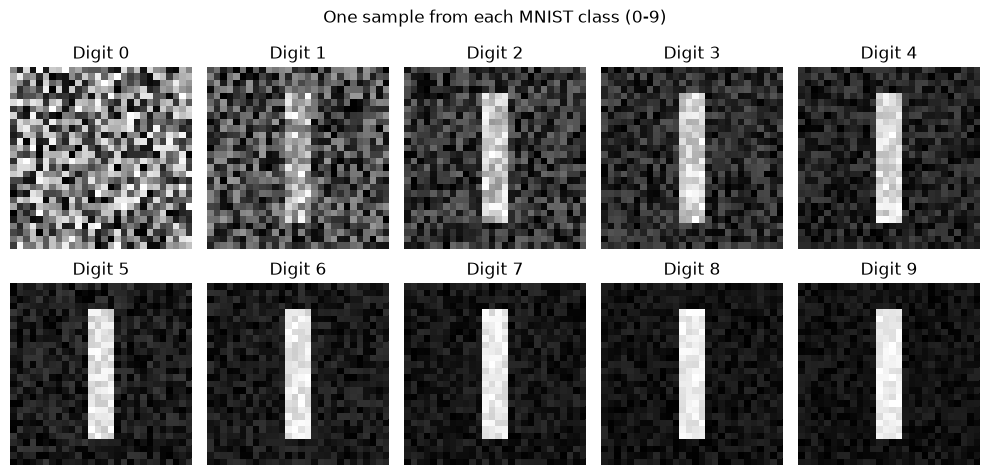

In [16]:
# Normalize only for display and later model input.
display_images = normalize_pixels(images_array)
if display_images.ndim == 2:
    display_images = display_images.reshape(len(display_images), 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit, axis in enumerate(axes.ravel()):
    matches = np.flatnonzero(labels_array == digit)
    if len(matches):
        axis.imshow(display_images[matches[0]], cmap='gray')
    axis.set_title(f'Digit {digit}')
    axis.axis('off')
fig.suptitle('One sample from each MNIST class (0-9)')
plt.tight_layout()
plt.show()

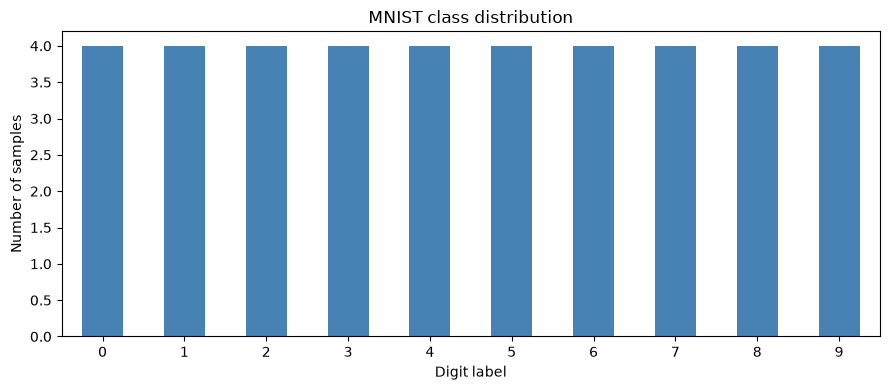

0    4
1    4
2    4
3    4
4    4
5    4
6    4
7    4
8    4
9    4
Name: count, dtype: int64


In [17]:
class_counts = pd.Series(labels_array).value_counts().sort_index()
class_counts = class_counts.reindex(range(10), fill_value=0)
ax = class_counts.plot(kind='bar', figsize=(9, 4), color='steelblue')
ax.set_title('MNIST class distribution')
ax.set_xlabel('Digit label')
ax.set_ylabel('Number of samples')
ax.set_xticklabels(range(10), rotation=0)
plt.tight_layout()
plt.show()
print(class_counts)

## Pre-process and save arrays

The helper normalizes pixels, flattens each 28 x 28 image into 784 features, creates a stratified 80/20 split, and saves the result to `data/mnist_processed.npz`. The saved arrays are ready for next week's model-training work.

In [18]:
saved_path = preprocess_and_save(images_array, labels_array, PROCESSED_PATH, reshape_format='flatten')
saved = np.load(saved_path)
print(f'Saved processed arrays to: {saved_path}')
for name in saved.files:
    print(f'{name}: {saved[name].shape}')

Saved processed arrays to: d:\Internship-Weekly-Logs\week-3\data\mnist_processed.npz
x_train: (32, 784)
x_test: (8, 784)
y_train: (32,)
y_test: (8,)
